In [2]:
import os
import glob
import re
import xarray as xr

# ============================================================
# Settings
# ============================================================
nc_dir = (
    "/nird/datalake/NS11071K/users/yongyub/LIM_Output_2026_6_nc"
)

# ============================================================
# Helper functions
# ============================================================
def get_ensemble_number(path):
    """Extract ensemble number from filename."""
    fname = os.path.basename(path)
    m = re.search(r"No_(\d+)", fname)
    if m is None:
        raise ValueError(f"Cannot find ensemble number from {fname}")
    return int(m.group(1))


def open_cesm2_group(nstate, period):
    """
    Open CESM2 LIM NetCDF files as one xarray Dataset.

    Output dims:
      ensemble, state_i, state_j, month, lead_index
    """
    pattern = os.path.join(
        nc_dir,
        f"CESM2_n{nstate}_config_No_*_{period}.nc"
    )

    files = sorted(glob.glob(pattern), key=get_ensemble_number)

    if len(files) == 0:
        raise FileNotFoundError(f"No files found: {pattern}")

    ens = [get_ensemble_number(f) for f in files]

    ds = xr.open_mfdataset(
        files,
        combine="nested",
        concat_dim=xr.DataArray(ens, dims="ensemble", name="ensemble"),
        parallel=False,
        decode_times=False
    )

    return ds


def open_obs_file(nstate, period="1998_2023"):
    """Open one OBS LIM NetCDF file."""
    path = os.path.join(
        nc_dir,
        f"OBS_n{nstate}_config_No_1_{period}.nc"
    )

    if not os.path.isfile(path):
        raise FileNotFoundError(path)

    ds = xr.open_dataset(path, decode_times=False)

    return ds

In [3]:
# ============================================================
# Load CESM2 datasets
# ============================================================
ds_cesm2_n2_1955_2020 = open_cesm2_group(2, "1955_2020")

ds_cesm2_n4_1955_2020 = open_cesm2_group(4, "1955_2020")
ds_cesm2_n4_1998_2020 = open_cesm2_group(4, "1998_2020")

ds_cesm2_n5_1955_2020 = open_cesm2_group(5, "1955_2020")

# ============================================================
# Load OBS datasets
# ============================================================
ds_obs_n2_1998_2023 = open_obs_file(2)
ds_obs_n4_1998_2023 = open_obs_file(4)

In [35]:
ds_cesm2_n5_1955_2020

<xarray.Dataset>
Dimensions:              (state_i: 5, state_j: 5, month: 12, lead_index: 7,
                          ensemble: 50)
Coordinates:
  * state_i              (state_i) float64 1.0 2.0 3.0 4.0 5.0
  * state_j              (state_j) float64 1.0 2.0 3.0 4.0 5.0
  * month                (month) float64 1.0 2.0 3.0 4.0 ... 9.0 10.0 11.0 12.0
  * lead_index           (lead_index) float64 1.0 2.0 3.0 4.0 5.0 6.0 7.0
  * ensemble             (ensemble) int64 1 2 3 4 5 6 7 ... 44 45 46 47 48 49 50
Data variables: (12/32)
    A_CS_CW              (ensemble, month, state_j, state_i) float64 dask.array<chunksize=(1, 12, 5, 5), meta=np.ndarray>
    A_CS_Colored         (ensemble, month, state_j, state_i) float64 dask.array<chunksize=(1, 12, 5, 5), meta=np.ndarray>
    A_CS_White           (ensemble, month, state_j, state_i) float64 dask.array<chunksize=(1, 12, 5, 5), meta=np.ndarray>
    A_ST_CW              (ensemble, state_j, state_i) float64 dask.array<chunksize=(1, 5, 5), meta=np.ndarray>
    A_ST_Colored         (ensemble, state_j, state_i) float64 dask.array<chunksize=(1, 5, 5), meta=np.ndarray>
    A_ST_White           (ensemble, state_j, state_i) float64 dask.array<chunksize=(1, 5, 5), meta=np.ndarray>
    ...                   ...
    Q_CS_CW              (ensemble, state_j, state_i) float64 dask.array<chunksize=(1, 5, 5), meta=np.ndarray>
    Q_CS_Colored         (ensemble, state_j, state_i) float64 dask.array<chunksize=(1, 5, 5), meta=np.ndarray>
    Q_ST_CW              (ensemble, state_j, state_i) float64 dask.array<chunksize=(1, 5, 5), meta=np.ndarray>
    Q_ST_Colored         (ensemble, state_j, state_i) float64 dask.array<chunksize=(1, 5, 5), meta=np.ndarray>
    tAp                  (ensemble, month) float64 dask.array<chunksize=(1, 12), meta=np.ndarray>
    tCp                  (ensemble, month) float64 dask.array<chunksize=(1, 12), meta=np.ndarray>

/nird/datapeak/NS9039K/users/yongyub/miniforge/envs/kdask/lib/python3.11/site-packages/xarray/core/common.py:615: FutureWarning: Updating MultiIndexed coordinate 'coupling' would corrupt indices for other variables: ['state_i', 'state_j']. This will raise an error in the future. Use `.drop_vars({'coupling', 'state_j', 'state_i'})` before assigning new coordinate values.
  data.coords.update(results)


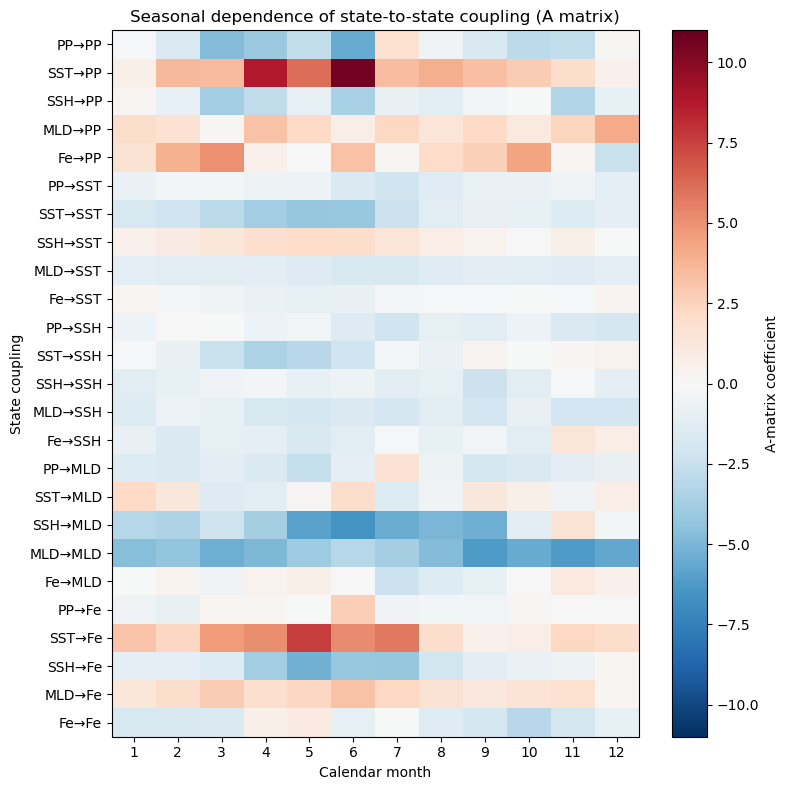

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

ds = ds_cesm2_n5_1955_2020

state_names = ["PP", "SST", "SSH", "MLD", "Fe"]

# --------------------------------------------------
# 1. Load & ensemble mean
# --------------------------------------------------
A = ds["A_CS_CW"].mean(dim="ensemble")

# Expected dims: state_i, state_j, month
# Convert to month, state_i, state_j
A = A.transpose("month", "state_i", "state_j")

# --------------------------------------------------
# 2. Flatten state_i, state_j
# --------------------------------------------------
A_flat = A.stack(coupling=("state_i", "state_j"))

coupling_labels = [
    f"{state_names[j]}→{state_names[i]}"
    for i in range(5)
    for j in range(5)
]

A_flat = A_flat.assign_coords(
    coupling=("coupling", coupling_labels)
)

# --------------------------------------------------
# 3. Transpose to coupling x month
# --------------------------------------------------
A_plot = A_flat.transpose("coupling", "month")

# --------------------------------------------------
# 4. Plot
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8))

A_plot.plot(
    ax=ax,
    cmap="RdBu_r",
    vmin=-11,
    vmax=+11,
    yincrease=False,
    cbar_kwargs={"label": "A-matrix coefficient"}
)

n_row = A_plot.sizes["coupling"]
n_col = A_plot.sizes["month"]

ax.set_ylim(n_row - 0.5, -0.5)
ax.set_xlim(0.5, 12.5)
ax.set_xticks(np.arange(1, 13))
ax.set_xticklabels(np.arange(1, 13))

ax.set_xlabel("Calendar month")
ax.set_ylabel("State coupling")
ax.set_title("Seasonal dependence of state-to-state coupling (A matrix)")

plt.tight_layout()
plt.show()

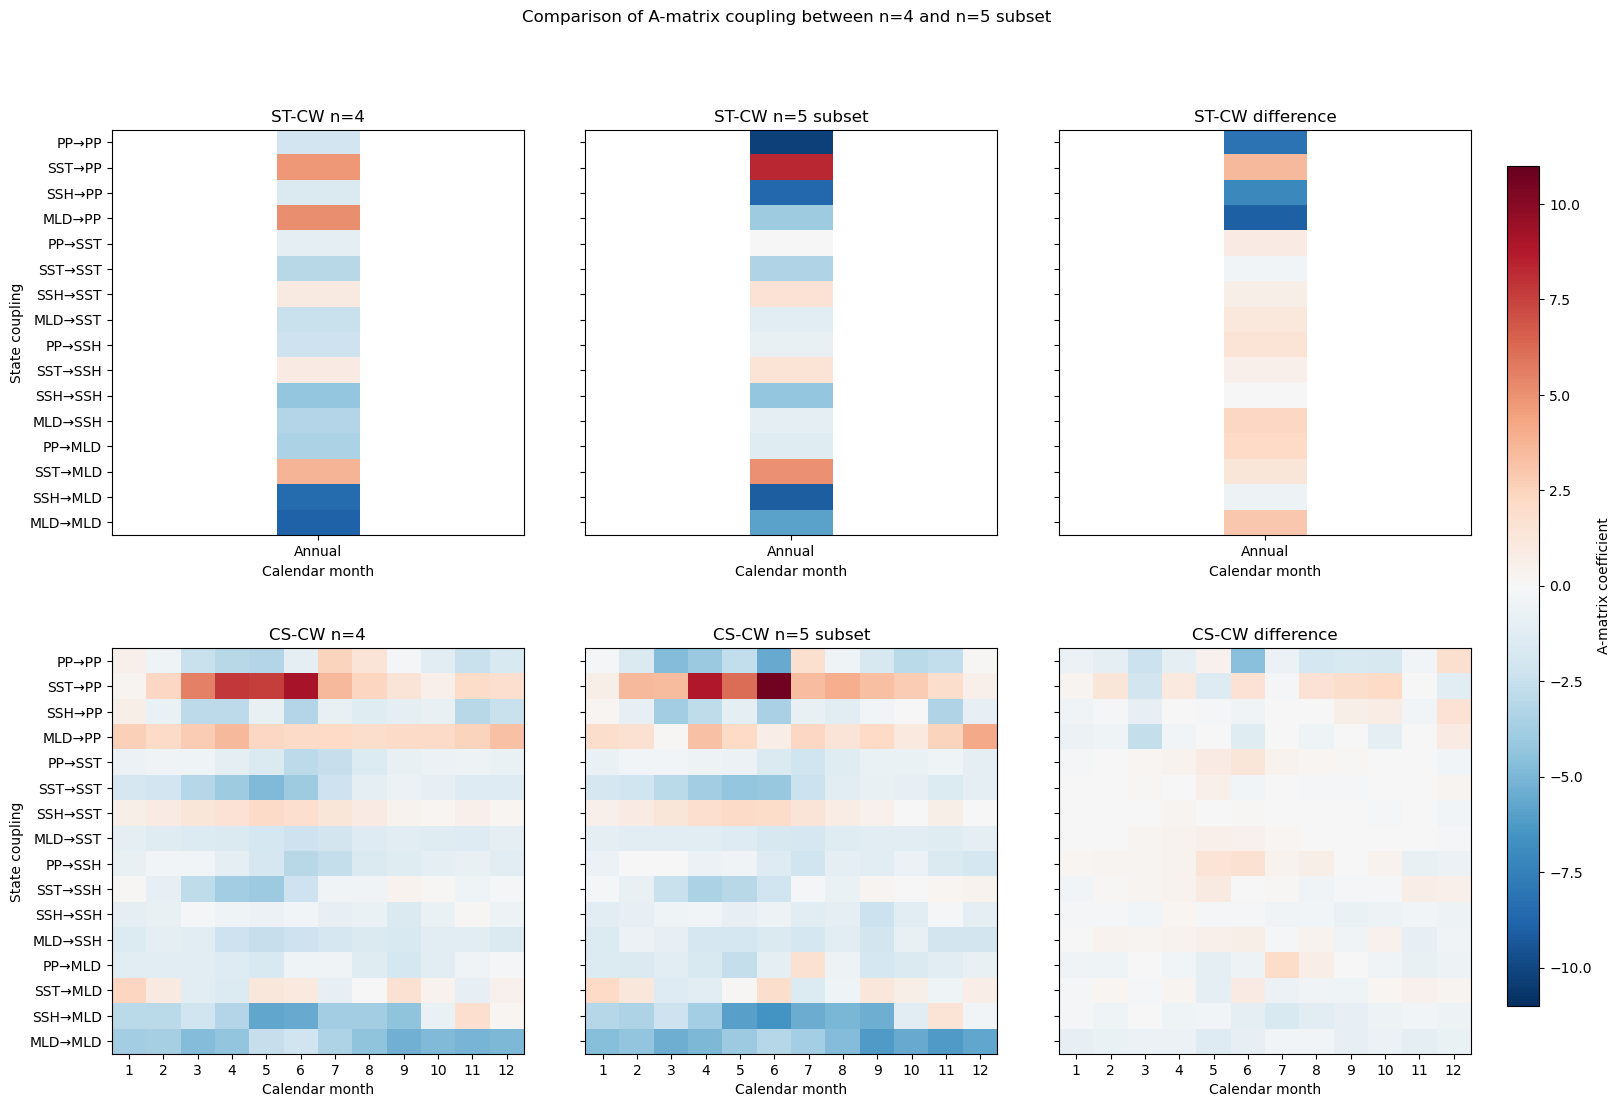

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

state_names_n4 = ["PP", "SST", "SSH", "MLD"]

# --------------------------------------------------
# Helper function
# --------------------------------------------------
def make_A_plot(ds, varname, state_names, nstate):
    # Load ensemble-mean A matrix
    A = ds[varname].mean(dim="ensemble")

    # Select only the first nstate x nstate block
    A = A.isel(state_i=slice(0, nstate), state_j=slice(0, nstate))

    # Add a dummy month dimension for stationary A matrices
    if "month" not in A.dims:
        A = A.expand_dims(month=[1])

    # Convert to month, state_i, state_j
    A = A.transpose("month", "state_i", "state_j")

    # Flatten state_i and state_j into a single coupling dimension
    A_flat = (
        A.stack(coupling=("state_i", "state_j"))
         .reset_index("coupling", drop=True)
    )

    # Create coupling labels
    coupling_labels = [
        f"{state_names[j]}→{state_names[i]}"
        for i in range(nstate)
        for j in range(nstate)
    ]

    A_flat = A_flat.assign_coords(
        coupling=("coupling", coupling_labels)
    )

    # Return as coupling x month
    return A_flat.transpose("coupling", "month")


# --------------------------------------------------
# Prepare ST-CW panels
# --------------------------------------------------
A_st_n4 = make_A_plot(
    ds_cesm2_n4_1955_2020,
    "A_ST_CW",
    state_names_n4,
    nstate=4
)

A_st_n5_subset = make_A_plot(
    ds_cesm2_n5_1955_2020,
    "A_ST_CW",
    state_names_n4,
    nstate=4
)

A_st_diff = A_st_n5_subset - A_st_n4

# --------------------------------------------------
# Prepare CS-CW panels
# --------------------------------------------------
A_cs_n4 = make_A_plot(
    ds_cesm2_n4_1955_2020,
    "A_CS_CW",
    state_names_n4,
    nstate=4
)

A_cs_n5_subset = make_A_plot(
    ds_cesm2_n5_1955_2020,
    "A_CS_CW",
    state_names_n4,
    nstate=4
)

A_cs_diff = A_cs_n5_subset - A_cs_n4

# --------------------------------------------------
# Plot settings
# --------------------------------------------------
vmin = -11
vmax = 11

plot_grid = [
    [A_st_n4, A_st_n5_subset, A_st_diff],
    [A_cs_n4, A_cs_n5_subset, A_cs_diff],
]

title_grid = [
    [
        "ST-CW n=4",
        "ST-CW n=5 subset",
        "ST-CW difference"
    ],
    [
        "CS-CW n=4",
        "CS-CW n=5 subset",
        "CS-CW difference"
    ],
]

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 12),
    sharey=True
)

fig.subplots_adjust(right=0.88, wspace=0.15, hspace=0.28)

for row in range(2):
    for col in range(3):

        ax = axes[row, col]
        A_plot = plot_grid[row][col]

        im = A_plot.plot.imshow(
            ax=ax,
            cmap="RdBu_r",
            vmin=vmin,
            vmax=vmax,
            yincrease=False,
            add_colorbar=False
        )

        n_row = A_plot.sizes["coupling"]

        ax.set_ylim(n_row - 0.5, -0.5)

        if row == 0:
            # ST-CW has one stationary column
            ax.set_xlim(0.5, 1.5)
            ax.set_xticks([1])
            ax.set_xticklabels(["Annual"])
        else:
            # CS-CW has monthly columns
            ax.set_xlim(0.5, 12.5)
            ax.set_xticks(np.arange(1, 13))
            ax.set_xticklabels(np.arange(1, 13))

        ax.set_xlabel("Calendar month")
        ax.set_title(title_grid[row][col])

        if col == 0:
            ax.set_ylabel("State coupling")
        else:
            ax.set_ylabel("")

# Create a dedicated axis for the colorbar
cax = fig.add_axes([0.90, 0.15, 0.018, 0.70])

cbar = fig.colorbar(
    im,
    cax=cax,
    extend="neither"
)

cbar.set_label("A-matrix coefficient")

fig.suptitle(
    "Comparison of A-matrix coupling between n=4 and n=5 subset",
    y=0.98
)

plt.show()

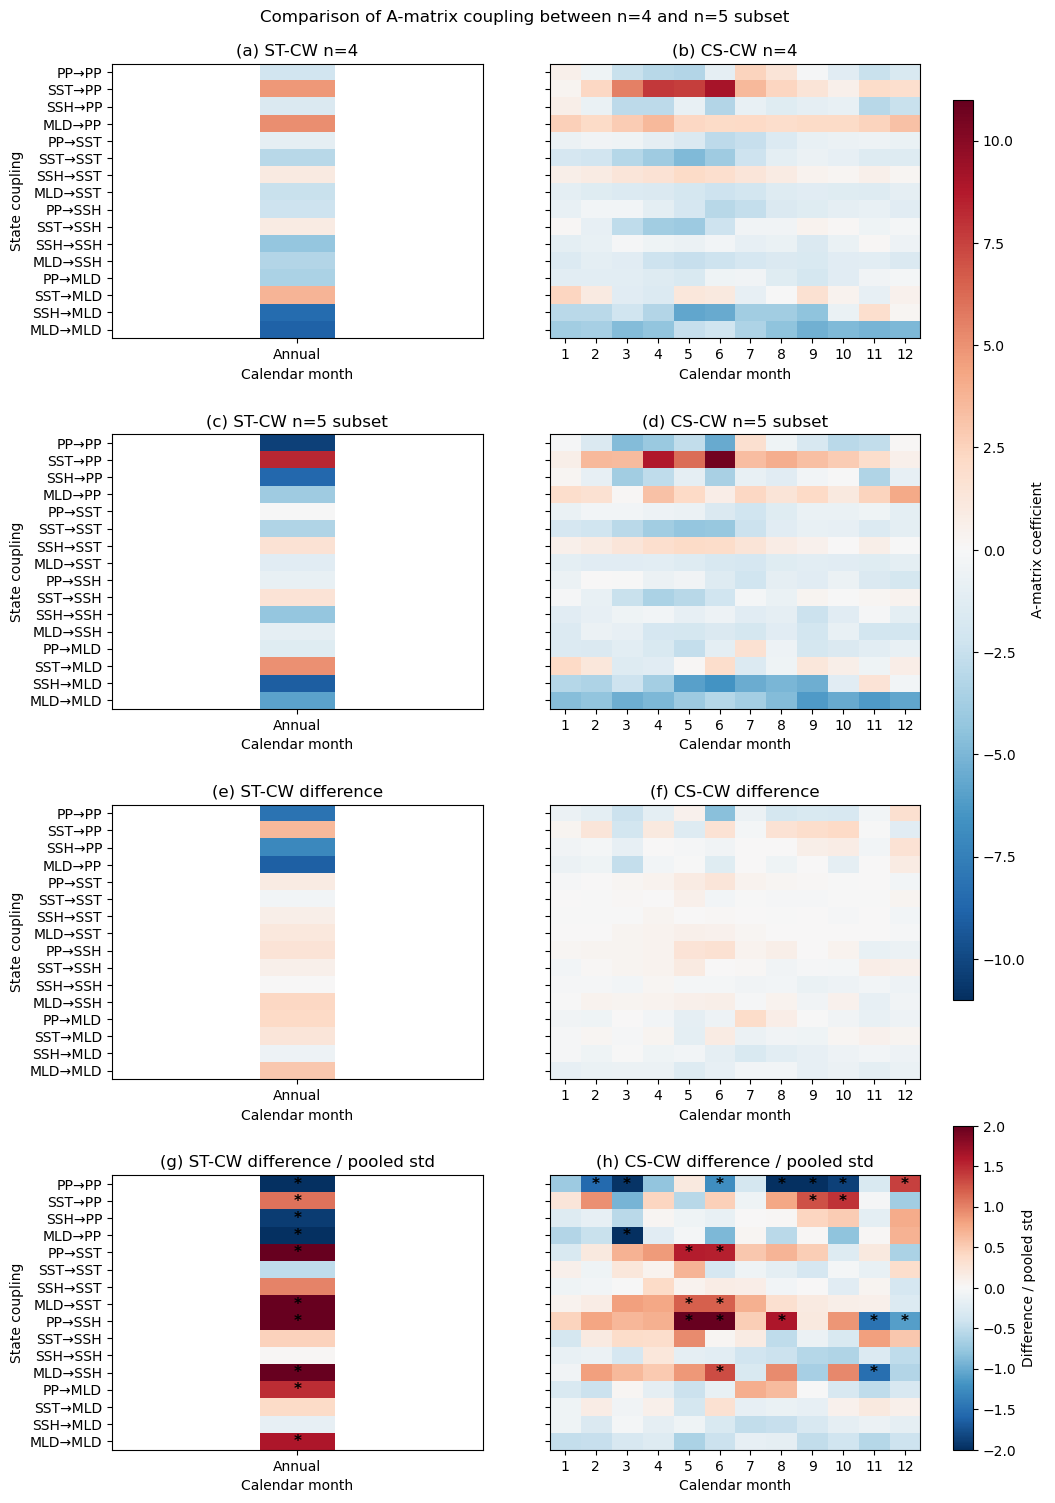

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

state_names_n4 = ["PP", "SST", "SSH", "MLD"]

# --------------------------------------------------
# Helper function: ensemble mean A matrix
# --------------------------------------------------
def make_A_mean_plot(ds, varname, state_names, nstate):
    # Load ensemble-mean A matrix
    A = ds[varname].mean(dim="ensemble")

    # Select only the first nstate x nstate block
    A = A.isel(
        state_i=slice(0, nstate),
        state_j=slice(0, nstate)
    )

    # Add a dummy month dimension for stationary A matrices
    if "month" not in A.dims:
        A = A.expand_dims(month=[1])

    # Convert to month, state_i, state_j
    A = A.transpose("month", "state_i", "state_j")

    # Flatten state_i and state_j into a single coupling dimension
    A_flat = (
        A.stack(coupling=("state_i", "state_j"))
         .reset_index("coupling", drop=True)
    )

    # Create coupling labels
    coupling_labels = [
        f"{state_names[j]}→{state_names[i]}"
        for i in range(nstate)
        for j in range(nstate)
    ]

    A_flat = A_flat.assign_coords(
        coupling=("coupling", coupling_labels)
    )

    # Return as coupling x month
    return A_flat.transpose("coupling", "month")


# --------------------------------------------------
# Helper function: ensemble std A matrix
# --------------------------------------------------
def make_A_std_plot(ds, varname, state_names, nstate):
    # Load ensemble standard deviation of A matrix
    A = ds[varname].std(dim="ensemble")

    # Select only the first nstate x nstate block
    A = A.isel(
        state_i=slice(0, nstate),
        state_j=slice(0, nstate)
    )

    # Add a dummy month dimension for stationary A matrices
    if "month" not in A.dims:
        A = A.expand_dims(month=[1])

    # Convert to month, state_i, state_j
    A = A.transpose("month", "state_i", "state_j")

    # Flatten state_i and state_j into a single coupling dimension
    A_flat = (
        A.stack(coupling=("state_i", "state_j"))
         .reset_index("coupling", drop=True)
    )

    # Create coupling labels
    coupling_labels = [
        f"{state_names[j]}→{state_names[i]}"
        for i in range(nstate)
        for j in range(nstate)
    ]

    A_flat = A_flat.assign_coords(
        coupling=("coupling", coupling_labels)
    )

    # Return as coupling x month
    return A_flat.transpose("coupling", "month")


# --------------------------------------------------
# Prepare ST-CW data
# --------------------------------------------------
A_st_n4 = make_A_mean_plot(
    ds_cesm2_n4_1955_2020,
    "A_ST_CW",
    state_names_n4,
    nstate=4
)

A_st_n5_subset = make_A_mean_plot(
    ds_cesm2_n5_1955_2020,
    "A_ST_CW",
    state_names_n4,
    nstate=4
)

A_st_diff = A_st_n5_subset - A_st_n4

A_st_std_n4 = make_A_std_plot(
    ds_cesm2_n4_1955_2020,
    "A_ST_CW",
    state_names_n4,
    nstate=4
)

A_st_std_n5 = make_A_std_plot(
    ds_cesm2_n5_1955_2020,
    "A_ST_CW",
    state_names_n4,
    nstate=4
)

A_st_pooled_std = np.sqrt((A_st_std_n4**2 + A_st_std_n5**2) / 2)
A_st_norm_diff = A_st_diff / A_st_pooled_std


# --------------------------------------------------
# Prepare CS-CW data
# --------------------------------------------------
A_cs_n4 = make_A_mean_plot(
    ds_cesm2_n4_1955_2020,
    "A_CS_CW",
    state_names_n4,
    nstate=4
)

A_cs_n5_subset = make_A_mean_plot(
    ds_cesm2_n5_1955_2020,
    "A_CS_CW",
    state_names_n4,
    nstate=4
)

A_cs_diff = A_cs_n5_subset - A_cs_n4

A_cs_std_n4 = make_A_std_plot(
    ds_cesm2_n4_1955_2020,
    "A_CS_CW",
    state_names_n4,
    nstate=4
)

A_cs_std_n5 = make_A_std_plot(
    ds_cesm2_n5_1955_2020,
    "A_CS_CW",
    state_names_n4,
    nstate=4
)

A_cs_pooled_std = np.sqrt((A_cs_std_n4**2 + A_cs_std_n5**2) / 2)
A_cs_norm_diff = A_cs_diff / A_cs_pooled_std


# --------------------------------------------------
# Plot grid
# --------------------------------------------------
plot_grid = [
    [A_st_n4,        A_cs_n4],
    [A_st_n5_subset, A_cs_n5_subset],
    [A_st_diff,      A_cs_diff],
    [A_st_norm_diff, A_cs_norm_diff],
]

title_grid = [
    ["(a) ST-CW n=4", "(b) CS-CW n=4"],
    ["(c) ST-CW n=5 subset", "(d) CS-CW n=5 subset"],
    ["(e) ST-CW difference", "(f) CS-CW difference"],
    ["(g) ST-CW difference / pooled std", "(h) CS-CW difference / pooled std"],
]

# --------------------------------------------------
# Color scales
# --------------------------------------------------
vmin_A = -11
vmax_A = 11

vmin_diff = -11
vmax_diff = 11

vmin_norm = -2
vmax_norm = 2

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, axes = plt.subplots(
    4, 2,
    figsize=(11, 18),
    sharey=True
)

fig.subplots_adjust(
    right=0.86,
    hspace=0.35,
    wspace=0.18
)

for row in range(4):
    for col in range(2):

        ax = axes[row, col]
        A_plot = plot_grid[row][col]

        if row in [0, 1]:
            vmin = vmin_A
            vmax = vmax_A
            cmap = "RdBu_r"
        elif row == 2:
            vmin = vmin_diff
            vmax = vmax_diff
            cmap = "RdBu_r"
        else:
            vmin = vmin_norm
            vmax = vmax_norm
            cmap = "RdBu_r"

        im = A_plot.plot.imshow(
            ax=ax,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            yincrease=False,
            add_colorbar=False
        )

        # --------------------------------------------------
        # Mark |difference| > 1 std
        # --------------------------------------------------
        if row == 3:
        
            values = A_plot.values
        
            for iy in range(values.shape[0]):
                for ix in range(values.shape[1]):
        
                    if np.isfinite(values[iy, ix]) and np.abs(values[iy, ix]) > 1:
        
                        ax.text(
                            ix + 1,          # x coordinate
                            iy,              # y coordinate
                            "*",
                            ha="center",
                            va="center",
                            fontsize=11,
                            color="black",
                            fontweight="bold",
                        )
                
        n_row = A_plot.sizes["coupling"]

        ax.set_ylim(n_row - 0.5, -0.5)

        if col == 0:
            # ST-CW has one stationary column
            ax.set_xlim(0.5, 1.5)
            ax.set_xticks([1])
            ax.set_xticklabels(["Annual"])
        else:
            # CS-CW has monthly columns
            ax.set_xlim(0.5, 12.5)
            ax.set_xticks(np.arange(1, 13))
            ax.set_xticklabels(np.arange(1, 13))

        ax.set_xlabel("Calendar month")
        ax.set_title(title_grid[row][col])

        if col == 0:
            ax.set_ylabel("State coupling")
        else:
            ax.set_ylabel("")

# --------------------------------------------------
# Colorbars
# --------------------------------------------------
# Colorbar for A and raw difference
cax1 = fig.add_axes([0.89, 0.36, 0.018, 0.50])
sm1 = plt.cm.ScalarMappable(
    cmap="RdBu_r",
    norm=plt.Normalize(vmin=vmin_A, vmax=vmax_A)
)
sm1.set_array([])
cbar1 = fig.colorbar(sm1, cax=cax1, extend="neither")
cbar1.set_label("A-matrix coefficient")

# Colorbar for normalized difference
cax2 = fig.add_axes([0.89, 0.11, 0.018, 0.18])
sm2 = plt.cm.ScalarMappable(
    cmap="RdBu_r",
    norm=plt.Normalize(vmin=vmin_norm, vmax=vmax_norm)
)
sm2.set_array([])
cbar2 = fig.colorbar(sm2, cax=cax2, extend="neither")
cbar2.set_label("Difference / pooled std")

fig.suptitle(
    "Comparison of A-matrix coupling between n=4 and n=5 subset",
    y=0.91
)

plt.show()

In [20]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr


def compare_A_n4_n5(varname):
    # Select A matrices
    A4_all = ds_cesm2_n4_1955_2020[varname]
    A5_all = ds_cesm2_n5_1955_2020[varname].isel(
        state_i=slice(0, 4),
        state_j=slice(0, 4)
    )

    # --------------------------------------------------
    # ST case: no month dimension
    # --------------------------------------------------
    if "month" not in A4_all.dims:
        A4_all = A4_all.transpose("ensemble", "state_i", "state_j")
        A5_all = A5_all.transpose("ensemble", "state_i", "state_j")

        rows_ens = []

        for ens in A4_all["ensemble"].values:
            x = A4_all.sel(ensemble=ens).values.ravel()
            y = A5_all.sel(ensemble=ens).values.ravel()

            mask = np.isfinite(x) & np.isfinite(y)
            x = x[mask]
            y = y[mask]

            diff = y - x

            pearson_r, pearson_p = pearsonr(x, y)
            spearman_r, spearman_p = spearmanr(x, y)

            rows_ens.append({
                "ensemble": int(ens),
                "pearson_r": pearson_r,
                "pearson_p": pearson_p,
                "spearman_r": spearman_r,
                "spearman_p": spearman_p,
                "rmse": np.sqrt(np.mean(diff**2)),
                "mae": np.mean(np.abs(diff)),
                "bias": np.mean(diff),
                "max_abs_diff": np.max(np.abs(diff)),
            })

        df_ens = pd.DataFrame(rows_ens)

        print(f"\n===== {varname}: Summary across ensembles =====")
        display(
            df_ens
            .drop(columns=["ensemble"])
            .agg(["mean", "std", "min", "max"])
        )

        return {
            "ensemble": df_ens,
            "ensemble_summary": df_ens.drop(columns=["ensemble"]).agg(
                ["mean", "std", "min", "max"]
            )
        }

    # --------------------------------------------------
    # CS case: month dimension exists
    # --------------------------------------------------
    A4_all = A4_all.transpose("ensemble", "month", "state_i", "state_j")
    A5_all = A5_all.transpose("ensemble", "month", "state_i", "state_j")

    rows_ens = []

    for ens in A4_all["ensemble"].values:
        x = A4_all.sel(ensemble=ens).values.ravel()
        y = A5_all.sel(ensemble=ens).values.ravel()

        mask = np.isfinite(x) & np.isfinite(y)
        x = x[mask]
        y = y[mask]

        diff = y - x

        pearson_r, pearson_p = pearsonr(x, y)
        spearman_r, spearman_p = spearmanr(x, y)

        rows_ens.append({
            "ensemble": int(ens),
            "pearson_r": pearson_r,
            "pearson_p": pearson_p,
            "spearman_r": spearman_r,
            "spearman_p": spearman_p,
            "rmse": np.sqrt(np.mean(diff**2)),
            "mae": np.mean(np.abs(diff)),
            "bias": np.mean(diff),
            "max_abs_diff": np.max(np.abs(diff)),
        })

    df_ens = pd.DataFrame(rows_ens)

    print(f"\n===== {varname}: Summary across ensembles =====")
    display(
        df_ens
        .drop(columns=["ensemble"])
        .agg(["mean", "std", "min", "max"])
    )

    rows_ens_month = []

    for ens in A4_all["ensemble"].values:
        for mon in A4_all["month"].values:
            x = A4_all.sel(ensemble=ens, month=mon).values.ravel()
            y = A5_all.sel(ensemble=ens, month=mon).values.ravel()

            mask = np.isfinite(x) & np.isfinite(y)
            x = x[mask]
            y = y[mask]

            diff = y - x

            pearson_r, pearson_p = pearsonr(x, y)
            spearman_r, spearman_p = spearmanr(x, y)

            rows_ens_month.append({
                "ensemble": int(ens),
                "month": int(mon),
                "pearson_r": pearson_r,
                "pearson_p": pearson_p,
                "spearman_r": spearman_r,
                "spearman_p": spearman_p,
                "rmse": np.sqrt(np.mean(diff**2)),
                "mae": np.mean(np.abs(diff)),
                "bias": np.mean(diff),
                "max_abs_diff": np.max(np.abs(diff)),
            })

    df_ens_month = pd.DataFrame(rows_ens_month)

    print(f"\n===== {varname}: Summary across ensemble-month pairs =====")
    display(
        df_ens_month
        .drop(columns=["ensemble", "month"])
        .agg(["mean", "std", "min", "max"])
    )

    df_month_summary = (
        df_ens_month
        .groupby("month")
        [["pearson_r", "spearman_r", "rmse", "mae", "bias", "max_abs_diff"]]
        .agg(["mean", "std"])
    )

    print(f"\n===== {varname}: Monthly summary =====")
    display(df_month_summary)

    return {
        "ensemble": df_ens,
        "ensemble_summary": df_ens.drop(columns=["ensemble"]).agg(
            ["mean", "std", "min", "max"]
        ),
        "ensemble_month": df_ens_month,
        "ensemble_month_summary": df_ens_month
            .drop(columns=["ensemble", "month"])
            .agg(["mean", "std", "min", "max"]),
        "monthly_summary": df_month_summary,
    }


# Run separately
stats_ST_CW = compare_A_n4_n5("A_ST_CW")
stats_CS_CW = compare_A_n4_n5("A_CS_CW")


===== A_ST_CW: Summary across ensembles =====


,pearson_r,pearson_p,spearman_r,spearman_p,rmse,mae,bias,max_abs_diff
mean,0.642501,0.023401,0.627471,0.026252,4.173464,2.905464,-0.490172,10.016762
std,0.123330,0.051841,0.127214,0.040128,1.428357,0.961331,0.331118,3.306222
min,0.259525,0.000020,0.335294,0.000056,1.854872,1.395345,-1.327845,4.713716
max,0.859179,0.331717,0.835294,0.204255,8.763316,5.568199,0.103974,23.615760



===== A_CS_CW: Summary across ensembles =====


,pearson_r,pearson_p,spearman_r,spearman_p,rmse,mae,bias,max_abs_diff
mean,0.885180,2.009695e-17,0.867269,4.682484e-24,1.397898,0.910008,-0.117023,6.688693
std,0.085045,1.421069e-16,0.079699,3.284666e-23,0.761228,0.461291,0.219320,4.934367
min,0.536821,1.442940e-126,0.626877,1.869521e-112,0.627839,0.413750,-0.811332,2.502835
max,0.975303,1.004848e-15,0.965053,2.322912e-22,4.260778,2.330812,0.419699,28.373547



===== A_CS_CW: Summary across ensemble-month pairs =====


,pearson_r,pearson_p,spearman_r,spearman_p,rmse,mae,bias,max_abs_diff
mean,0.894316,4.435574e-03,0.841074,9.470126e-03,1.272873,0.910008,-0.117023,3.116680
std,0.116027,4.002561e-02,0.143225,6.092750e-02,0.950420,0.631816,0.324382,2.581459
min,-0.065945,2.557836e-17,0.032353,5.065588e-17,0.195488,0.139030,-1.725106,0.351191
max,0.997333,8.082801e-01,0.997059,9.053195e-01,10.249643,6.151763,1.114201,28.373547



===== A_CS_CW: Monthly summary =====


pearson_r           spearman_r                rmse                 mae  \
           mean       std       mean       std      mean       std      mean   
month                                                                          
1      0.932937  0.074296   0.894176  0.116415  0.805017  0.569824  0.588964   
2      0.912915  0.075453   0.884765  0.090857  0.913768  0.570130  0.647545   
3      0.844657  0.189756   0.850647  0.172674  1.448444  0.775763  0.995491   
4      0.950110  0.059972   0.907941  0.087224  1.206989  0.877590  0.880316   
5      0.898183  0.126428   0.821882  0.138639  1.515393  1.092524  1.120600   
6      0.889693  0.128247   0.765294  0.174441  2.068292  1.707489  1.450473   
7      0.885982  0.106284   0.865059  0.107212  1.433986  1.176090  0.982508   
8      0.887892  0.105266   0.830529  0.131838  1.139193  0.617973  0.817377   
9      0.923345  0.060743   0.861176  0.094120  1.204184  0.687559  0.845711   
10     0.832335  0.128607   0.782588  0.166225  1.249869  0.716255  0.870199   
11     0.908040  0.100308   0.855176  0.142970  1.061044  0.705345  0.792113   
12     0.865704  0.122992   0.773647  0.175829  1.228296  0.684700  0.928795   

                     bias           max_abs_diff            
            std      mean       std         mean       std  
month                                                       
1      0.386584 -0.203703  0.276422     1.863455  1.494841  
2      0.391316 -0.063779  0.203672     2.323321  1.547379  
3      0.519937 -0.471954  0.401575     3.607195  2.101455  
4      0.546713  0.071417  0.323145     2.986394  2.594953  
5      0.666393  0.001217  0.389069     3.565068  3.059756  
6      1.104248 -0.157604  0.321475     5.378150  4.672486  
7      0.731977 -0.043307  0.327227     3.867569  3.408310  
8      0.449792 -0.093094  0.200689     2.713773  1.461592  
9      0.499728 -0.153490  0.321186     2.957664  1.711559  
10     0.520761 -0.074287  0.230868     3.105613  1.842273  
11     0.512266 -0.215963  0.289406     2.433178  1.748074  
12     0.511459  0.000270  0.189137     2.598775  1.381775

In [34]:
import numpy as np
import pandas as pd
import xarray as xr
from statsmodels.stats.outliers_influence import variance_inflation_factor

# --------------------------------------------------
# Calculate VIF
# --------------------------------------------------
def calculate_vif(ds, var_names):
    """
    ds : xarray.Dataset containing state variables
    var_names : list of variable names
    """

    # Stack all dimensions except state variables
    X = np.column_stack([
        ds[var].values.reshape(-1)
        for var in var_names
    ])

    # Remove samples containing NaN
    mask = np.all(np.isfinite(X), axis=1)
    X = X[mask]

    vif = pd.DataFrame({
        "Variable": var_names,
        "VIF": [
            variance_inflation_factor(X, i)
            for i in range(X.shape[1])
        ]
    })

    return vif


# --------------------------------------------------
# Example
# --------------------------------------------------
var_names = ["PP", "SST", "SSH", "MLD", "Fe"]

vif = calculate_vif(ds_state, var_names)

print(vif)

NameError: name 'ds_state' is not defined

In [24]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr


def compare_single_coupling_n4_n5_by_member(
    varname,
    target_idx,
    predictor_idx,
    coupling_name
):
    # Select one coupling coefficient from n4 and n5
    A4 = ds_cesm2_n4_1955_2020[varname].isel(
        state_i=target_idx,
        state_j=predictor_idx
    )

    A5 = ds_cesm2_n5_1955_2020[varname].isel(
        state_i=target_idx,
        state_j=predictor_idx
    )

    # --------------------------------------------------
    # ST case: only one value per ensemble
    # --------------------------------------------------
    if "month" not in A4.dims:
        A4 = A4.transpose("ensemble")
        A5 = A5.transpose("ensemble")

        rows = []

        for ens in A4["ensemble"].values:
            x = float(A4.sel(ensemble=ens).values)
            y = float(A5.sel(ensemble=ens).values)

            rows.append({
                "ensemble": int(ens),
                "A_n4": x,
                "A_n5_subset": y,
                "diff_n5_minus_n4": y - x,
                "abs_diff": abs(y - x),
            })

        df = pd.DataFrame(rows)

        summary = (
            df[["A_n4", "A_n5_subset", "diff_n5_minus_n4", "abs_diff"]]
            .agg(["mean", "std", "min", "max"])
        )

        print(f"\n===== {varname}: {coupling_name}, summary across members =====")
        display(summary)

        return {
            "member_values": df,
            "summary": summary
        }

    # --------------------------------------------------
    # CS case: one monthly series per ensemble
    # --------------------------------------------------
    A4 = A4.transpose("ensemble", "month")
    A5 = A5.transpose("ensemble", "month")

    rows = []

    for ens in A4["ensemble"].values:
        x = A4.sel(ensemble=ens).values
        y = A5.sel(ensemble=ens).values

        mask = np.isfinite(x) & np.isfinite(y)
        x = x[mask]
        y = y[mask]

        diff = y - x

        pearson_r, pearson_p = pearsonr(x, y)
        spearman_r, spearman_p = spearmanr(x, y)

        rows.append({
            "ensemble": int(ens),
            "pearson_r_month_series": pearson_r,
            "pearson_p_month_series": pearson_p,
            "spearman_r_month_series": spearman_r,
            "spearman_p_month_series": spearman_p,
            "rmse_month_series": np.sqrt(np.mean(diff**2)),
            "mae_month_series": np.mean(np.abs(diff)),
            "bias_month_series": np.mean(diff),
            "max_abs_diff_month_series": np.max(np.abs(diff)),
            "mean_A_n4": np.mean(x),
            "mean_A_n5_subset": np.mean(y),
        })

    df = pd.DataFrame(rows)

    summary = (
        df.drop(columns=["ensemble"])
        .agg(["mean", "std", "min", "max"])
    )

    print(f"\n===== {varname}: {coupling_name}, summary across members =====")
    display(summary)

    return {
        "member_values": df,
        "summary": summary
    }


# SST -> PP
target_idx = 0
predictor_idx = 1

stats_ST_CW_SST_to_PP = compare_single_coupling_n4_n5_by_member(
    "A_ST_CW",
    target_idx,
    predictor_idx,
    "SST→PP"
)

stats_CS_CW_SST_to_PP = compare_single_coupling_n4_n5_by_member(
    "A_CS_CW",
    target_idx,
    predictor_idx,
    "SST→PP"
)


===== A_ST_CW: SST→PP, summary across members =====


,A_n4,A_n5_subset,diff_n5_minus_n4,abs_diff
mean,4.775834,8.322441,3.546607,3.998143
std,1.868425,4.286919,4.416305,4.003437
min,0.534433,3.655663,-2.017861,0.012400
max,8.388902,23.257647,16.762945,16.762945



===== A_CS_CW: SST→PP, summary across members =====


,pearson_r_month_series,pearson_p_month_series,spearman_r_month_series,spearman_p_month_series,rmse_month_series,mae_month_series,bias_month_series,max_abs_diff_month_series,mean_A_n4,mean_A_n5_subset
mean,0.846417,7.175746e-03,0.758601,3.592291e-02,1.987665,1.614772,0.412503,3.891707,3.695030,4.107533
std,0.124967,1.687092e-02,0.178887,1.088468e-01,1.386686,1.096248,0.628843,2.501773,0.695206,0.733526
min,0.535623,5.358268e-10,0.132867,1.301673e-10,0.643398,0.537891,-1.995876,1.075147,2.439889,1.973316
max,0.990712,7.268512e-02,0.993007,6.805975e-01,7.452953,5.548624,2.307249,13.588783,6.198718,6.254113


In [41]:
import numpy as np
import pandas as pd


def diagnose_K(K):
    K = np.asarray(K, dtype=float)

    # Remove tiny numerical asymmetry
    K = 0.5 * (K + K.T)

    eigvals = np.linalg.eigvalsh(K)

    # Singular values used by np.linalg.matrix_rank
    singular_values = np.linalg.svd(K, compute_uv=False)
    smax = singular_values.max()
    smin = singular_values.min()
    matrix_size_factor = max(K.shape)
    eps = np.finfo(singular_values.dtype).eps

    # Default tolerance used by np.linalg.matrix_rank when tol=None
    rank_tol = smax * matrix_size_factor * eps

    rank_manual = int(np.sum(singular_values > rank_tol))
    rank_numpy = np.linalg.matrix_rank(K)

    sign, logdet = np.linalg.slogdet(K)

    return {
        "det": np.linalg.det(K),
        "logdet": logdet if sign > 0 else np.nan,

        "rank": rank_numpy,
        "rank_manual": rank_manual,
        "rank_deficient": rank_numpy < K.shape[0],

        "min_eig": eigvals.min(),
        "max_eig": eigvals.max(),
        "condition_number": np.linalg.cond(K),

        # Rank tolerance diagnostics
        "smax": smax,
        "smin": smin,
        "matrix_size_factor": matrix_size_factor,
        "machine_eps": eps,
        "rank_tol": rank_tol,
        "smin_over_tol": smin / rank_tol,
    }


def diagnose_dataset(ds, varname):
    K = ds[varname]

    # Select K(0)
    for lead_dim in ["lead_index", "lead"]:
        if lead_dim in K.dims:
            K = K.isel({lead_dim: 0})

    # ST matrices should not have seasonal dependence.
    # If a month dimension exists for storage consistency, use one month only.
    is_st = "_ST_" in varname

    if is_st and "month" in K.dims:
        K = K.isel(month=0)

    rows = []

    if "month" not in K.dims:
        K = K.transpose("ensemble", "state_j", "state_i")

        for ens in K["ensemble"].values:
            out = diagnose_K(K.sel(ensemble=ens).values)
            out["ensemble"] = int(ens)
            rows.append(out)

    else:
        K = K.transpose("ensemble", "month", "state_j", "state_i")

        for ens in K["ensemble"].values:
            for mon in K["month"].values:
                out = diagnose_K(K.sel(ensemble=ens, month=mon).values)
                out["ensemble"] = int(ens)
                out["month"] = int(mon)
                rows.append(out)

    return pd.DataFrame(rows)


def mean_std_string(series, precision=3):
    return f"{series.mean():.{precision}f} ± {series.std():.{precision}f}"


def sci_mean_std_string(series, precision=3):
    return f"{series.mean():.{precision}e} ± {series.std():.{precision}e}"


def make_table_row(label, df):
    ncase = len(df)
    n_rank_def = int(df["rank_deficient"].sum())

    return {
        "Configuration": label,
        "Determinant of K": mean_std_string(df["det"]),
        "Rank": mean_std_string(df["rank"], precision=1),
        "Rank deficient": f"{n_rank_def}/{ncase}",
        "Minimum eigenvalue": mean_std_string(df["min_eig"]),
        "Maximum eigenvalue": mean_std_string(df["max_eig"]),
        "Condition number": mean_std_string(df["condition_number"]),
    }


def make_rank_tol_row(label, df):
    return {
        "Configuration": label,
        "Largest singular value": mean_std_string(df["smax"]),
        "Smallest singular value": sci_mean_std_string(df["smin"]),
        "Matrix size factor": mean_std_string(df["matrix_size_factor"], precision=1),
        "Machine epsilon": sci_mean_std_string(df["machine_eps"]),
        "Default rank tolerance": sci_mean_std_string(df["rank_tol"]),
        "Smallest singular / tolerance": sci_mean_std_string(df["smin_over_tol"]),
        "Numerical rank": mean_std_string(df["rank"], precision=1),
    }


# Run diagnostics
diag_n4_ST = diagnose_dataset(ds_cesm2_n4_1955_2020, "K_ST_CW")
diag_n5_ST = diagnose_dataset(ds_cesm2_n5_1955_2020, "K_ST_CW")

diag_n4_CS = diagnose_dataset(ds_cesm2_n4_1955_2020, "K_CS_CW")
diag_n5_CS = diagnose_dataset(ds_cesm2_n5_1955_2020, "K_CS_CW")


# Main table
df_K_table = pd.DataFrame([
    make_table_row("K_ST_CW (n=4)", diag_n4_ST),
    make_table_row("K_ST_CW (n=5)", diag_n5_ST),
    make_table_row("K_CS_CW (n=4)", diag_n4_CS),
    make_table_row("K_CS_CW (n=5)", diag_n5_CS),
]).set_index("Configuration")

display(df_K_table)


# Rank tolerance table
df_rank_tol_table = pd.DataFrame([
    make_rank_tol_row("K_ST_CW (n=4)", diag_n4_ST),
    make_rank_tol_row("K_ST_CW (n=5)", diag_n5_ST),
    make_rank_tol_row("K_CS_CW (n=4)", diag_n4_CS),
    make_rank_tol_row("K_CS_CW (n=5)", diag_n5_CS),
]).set_index("Configuration")

display(df_rank_tol_table)

,Determinant of K,Rank,Rank deficient,Minimum eigenvalue,Maximum eigenvalue,Condition number
Configuration,,,,,,
K_ST_CW (n=4),0.045 ± 0.010,4.0 ± 0.0,0/50,0.047 ± 0.009,2.391 ± 0.058,52.889 ± 11.545
K_ST_CW (n=5),0.022 ± 0.006,5.0 ± 0.0,0/50,0.047 ± 0.009,2.876 ± 0.098,64.113 ± 14.462
K_CS_CW (n=4),0.020 ± 0.014,4.0 ± 0.0,0/600,0.034 ± 0.015,2.760 ± 0.593,113.666 ± 135.353
K_CS_CW (n=5),0.012 ± 0.050,5.0 ± 0.0,0/600,0.030 ± 0.017,3.456 ± 1.221,197.271 ± 260.495


,Largest singular value,Smallest singular value,Matrix size factor,Machine epsilon,Default rank tolerance,Smallest singular / tolerance,Numerical rank
Configuration,,,,,,,
K_ST_CW (n=4),2.391 ± 0.058,4.718e-02 ± 9.436e-03,4.0 ± 0.0,2.220e-16 ± 0.000e+00,2.124e-15 ± 5.135e-17,2.228e+13 ± 4.790e+12,4.0 ± 0.0
K_ST_CW (n=5),2.876 ± 0.098,4.684e-02 ± 9.313e-03,5.0 ± 0.0,2.220e-16 ± 0.000e+00,3.193e-15 ± 1.091e-16,1.474e+13 ± 3.245e+12,5.0 ± 0.0
K_CS_CW (n=4),2.760 ± 0.593,3.387e-02 ± 1.495e-02,4.0 ± 0.0,2.220e-16 ± 0.000e+00,2.451e-15 ± 5.264e-16,1.486e+13 ± 8.172e+12,4.0 ± 0.0
K_CS_CW (n=5),3.456 ± 1.221,3.023e-02 ± 1.661e-02,5.0 ± 0.0,2.220e-16 ± 0.000e+00,3.837e-15 ± 1.356e-15,9.105e+12 ± 6.559e+12,5.0 ± 0.0


In [26]:
import numpy as np
import pandas as pd

state_names = ["PP", "SST", "SSH", "MLD", "Fe"]

# --------------------------------------------------
# Select K(0)
# --------------------------------------------------
K0 = (
    ds_cesm2_n5_1955_2020["K_obs"]
    .sel(lead_index=1)          # K(0)
    .mean("ensemble")           # ensemble mean
    .values
)

# --------------------------------------------------
# Convert covariance -> correlation
# --------------------------------------------------
std = np.sqrt(np.diag(K0))

corr = K0 / np.outer(std, std)

corr_df = pd.DataFrame(
    corr,
    index=state_names,
    columns=state_names,
)

display(corr_df.round(3))

,PP,SST,SSH,MLD,Fe
PP,1.000,-0.289,-0.498,-0.215,0.537
SST,-0.289,1.000,0.922,-0.540,-0.508
SSH,-0.498,0.922,1.000,-0.384,-0.560
MLD,-0.215,-0.540,-0.384,1.000,0.322
Fe,0.537,-0.508,-0.560,0.322,1.000


In [37]:
import os
import glob
import re
import numpy as np
import pandas as pd
import xarray as xr
from statsmodels.stats.outliers_influence import variance_inflation_factor

# --------------------------------------------------
# Settings
# --------------------------------------------------
lim_dir = "/nird/datalake/NS11071K/users/yongyub/LIM_input"

state_names = ["PP", "SST", "SSH", "MLD", "Fe"]

file_pattern = os.path.join(lim_dir, "NPP_LIM_n_5_No_*.nc")


# --------------------------------------------------
# Helper
# --------------------------------------------------
def get_ensemble_number(path):
    fname = os.path.basename(path)
    m = re.search(r"No_(\d+)", fname)
    if m is None:
        raise ValueError(f"Cannot find ensemble number from {fname}")
    return int(m.group(1))


def calculate_vif_from_xvec(xvec):
    # xvec shape should be time x state
    X = np.asarray(xvec, dtype=float)

    mask = np.all(np.isfinite(X), axis=1)
    X = X[mask, :]

    vif = [
        variance_inflation_factor(X, i)
        for i in range(X.shape[1])
    ]

    return vif


# --------------------------------------------------
# Read files and calculate VIF for each ensemble
# --------------------------------------------------
files = sorted(glob.glob(file_pattern), key=get_ensemble_number)

rows = []

for f in files:
    ens = get_ensemble_number(f)

    ds = xr.open_dataset(f)

    X = ds["xvec"].transpose("time", "state").values

    vif = calculate_vif_from_xvec(X)

    row = {"ensemble": ens}
    for name, value in zip(state_names, vif):
        row[name] = value

    rows.append(row)

    ds.close()

df_vif = pd.DataFrame(rows).sort_values("ensemble")

# --------------------------------------------------
# Summary table
# --------------------------------------------------
df_vif_summary = (
    df_vif
    .drop(columns="ensemble")
    .agg(["mean", "std", "min", "max"])
    .T
)

display(df_vif_summary)

,mean,std,min,max
PP,2.760389,0.310057,2.227225,3.450766
SST,10.905482,2.082457,7.683318,16.106550
SSH,11.724640,2.410996,8.111085,18.768141
MLD,2.118164,0.157872,1.768303,2.517752
Fe,2.046560,0.188894,1.583481,2.612463
